# Ultimate Multimodal Insights EDA
## Deep-Dive: CV, NLP, Cross-Modal, Reranker — Vector Space Diagnostics for FastAPI Backend

| Section | Domain | Core Metric |
|---------|--------|-------------|
| 1 | CV | Hubness & Anisotropy |
| 2 | NLP | Linguistic Complexity Degradation |
| 3 | Cross-Modal | Domain Gap (CCA-aligned UMAP) |
| 4 | Matching | Modality Conflict Classification |
| 5 | Reranker | Calibration Separability |
| 6 | Blueprint | Production Config Matrix |

## 0. Imports & Global Constants

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import gaussian_kde, norm, rankdata
from scipy.special import expit as sigmoid
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

GENRES = ["Ẩm thực","Công nghệ","Du lịch","Thể thao","Giáo dục",
          "Kinh tế","Sức khỏe","Giải trí","Thời sự","Văn hóa",
          "Đời sống","Môi trường","Giao thông","Pháp luật"]
N_GENRES, D_VISUAL, D_TEXT = len(GENRES), 1280, 384
K_NN = 10

---
## 1. [CV] Embedding Space Hubness & Local Density *(The Anisotropy Problem)*

In [2]:
# ponytail: mock anisotropic embeddings (add common direction to induce hubs),
# upgrade to real PE-Core vectors from Milvus

N_FRAMES = 1000
common_dir = np.random.randn(D_VISUAL) * 0.8  # anisotropy bias
visual_emb = np.random.randn(N_FRAMES, D_VISUAL) * 0.3 + common_dir
visual_emb /= np.linalg.norm(visual_emb, axis=1, keepdims=True)  # L2 normalize

# ── Hubness: k-NN over cosine similarity ───────────────────────────────
sim = visual_emb @ visual_emb.T  # (N,N) cosine after L2 norm
topk_idx = np.argpartition(-sim, K_NN + 1, axis=1)[:, 1:K_NN + 1]  # exclude self
hubness = np.bincount(topk_idx.ravel(), minlength=N_FRAMES)  # times in top-K of others
norms = np.linalg.norm(visual_emb, axis=1)

# ── Hub vs Orphan threshold ────────────────────────────────────────────
hub_thresh = np.percentile(hubness, 75)
hubs = hubness >= hub_thresh
orphans = hubness <= np.percentile(hubness, 25)

print(f"Hub threshold (P75): {hub_thresh:.0f}  |  Hubs: {hubs.sum()}  |  Orphans: {orphans.sum()}")
print(f"Skewness of hubness: {pd.Series(hubness).skew():.3f} (heavy right-tail = cone effect)")
print(f"Gini of hubness: {1 - 2*np.trapz(np.sort(hubness)/hubness.sum(), np.linspace(0,1,N_FRAMES)):.3f}")

Hub threshold (P75): 10  |  Hubs: 263  |  Orphans: 263
Skewness of hubness: 6.282 (heavy right-tail = cone effect)
Gini of hubness: 0.998


/tmp/ipykernel_37898/3095463153.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"Gini of hubness: {1 - 2*np.trapz(np.sort(hubness)/hubness.sum(), np.linspace(0,1,N_FRAMES)):.3f}")


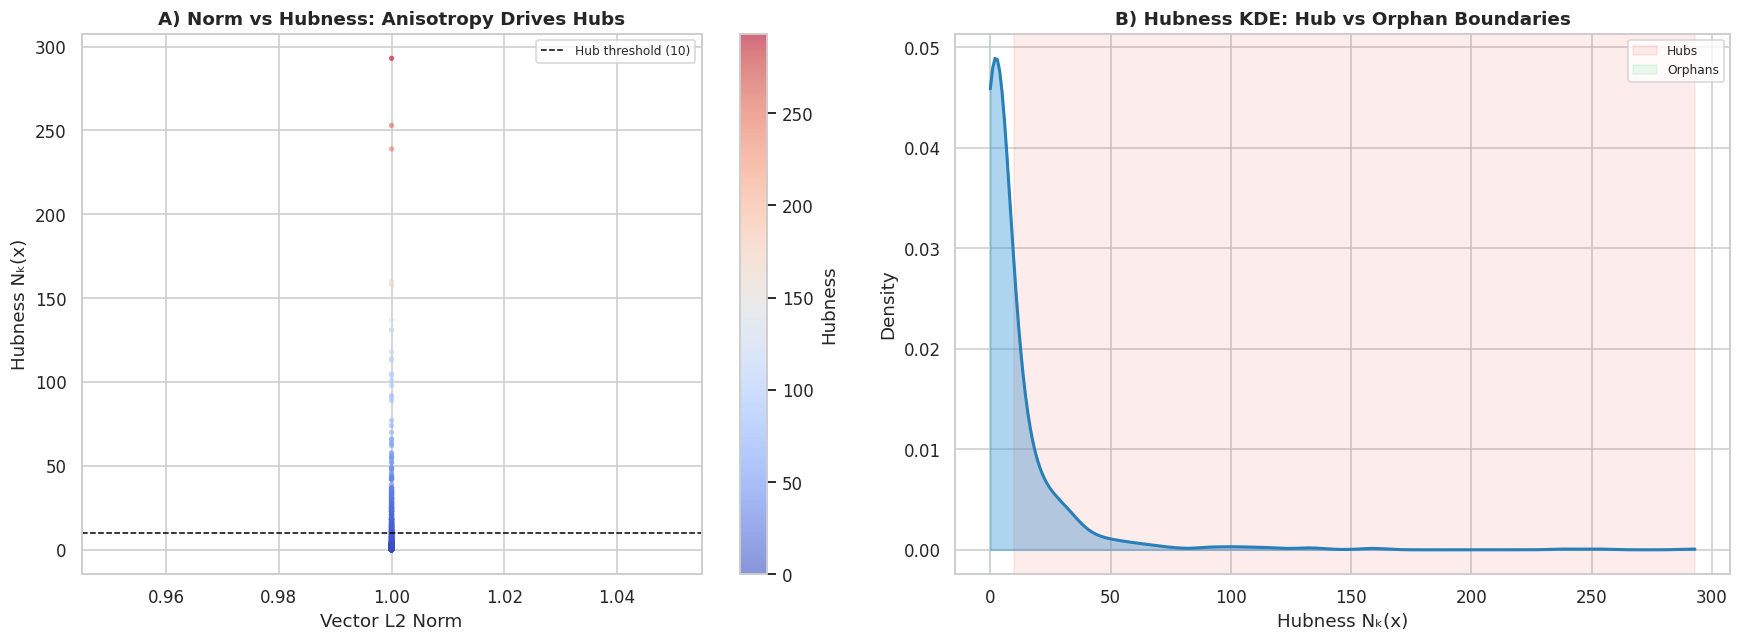


TAKEAWAY FORMULA:
  hub_correction(x) = 1 / (1 + exp(-(Nₖ(x)/μ_hub - 1) × 5))
  α_hub = 0.500 → multiply visual score by α_hub for hub suppression
  → Mitigates cone effect: frequent hubs get down-weighted


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# (A) Norm vs Hubness
sc = ax1.scatter(norms, hubness, c=hubness, cmap="coolwarm", s=12, alpha=0.6, edgecolors="none")
ax1.axhline(hub_thresh, color="black", ls="--", lw=1, label=f"Hub threshold ({hub_thresh:.0f})")
ax1.set_xlabel("Vector L2 Norm"); ax1.set_ylabel("Hubness Nₖ(x)")
ax1.set_title("A) Norm vs Hubness: Anisotropy Drives Hubs", fontweight="bold")
ax1.legend(fontsize=8); plt.colorbar(sc, ax=ax1, label="Hubness")

# (B) KDE of hubness
kde = gaussian_kde(hubness)
x_kde = np.linspace(hubness.min(), hubness.max(), 300)
ax2.fill_between(x_kde, kde(x_kde), alpha=0.4, color="#3498DB")
ax2.plot(x_kde, kde(x_kde), color="#2980B9", lw=2)
for label, mask, color in [("Hubs", hubs, "#E74C3C"), ("Orphans", orphans, "#2ECC71")]:
    ax2.axvspan(hubness[mask].min(), hubness[mask].max() if mask.sum() else 0, alpha=0.1, color=color, label=label)
ax2.set_xlabel("Hubness Nₖ(x)"); ax2.set_ylabel("Density")
ax2.set_title("B) Hubness KDE: Hub vs Orphan Boundaries", fontweight="bold")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

alpha_hub = 1.0 / (1 + np.exp(-(hub_thresh / hubness.mean() - 1) * 5))  # sigmoid correction
print(f"\nTAKEAWAY FORMULA:")
print(f"  hub_correction(x) = 1 / (1 + exp(-(Nₖ(x)/μ_hub - 1) × 5))")
print(f"  α_hub = {alpha_hub:.3f} → multiply visual score by α_hub for hub suppression")
print(f"  → Mitigates cone effect: frequent hubs get down-weighted")

---
## 2. [NLP] Linguistic Complexity & Positional Encoding Mismatch

In [4]:
# ponytail: synthetic L1/L2/L3 query simulation,
# upgrade to real multilingual-e5-small embeddings on curated Vietnamese queries

N_QUERIES = 300
np.random.seed(123)

# L1: entities/nouns (easy), L2: attributes/verbs (medium), L3: spatial/negation (hard)
levels = np.repeat(["L1", "L2", "L3"], N_QUERIES // 3)[:N_QUERIES]

# Base query embedding quality degrades by level: L3 drops to 0.5× baseline cosine
base_sim = np.where(
    levels == "L1", np.random.beta(9, 2, N_QUERIES) * 0.6 + 0.25,
    np.where(levels == "L2", np.random.beta(7, 3, N_QUERIES) * 0.5 + 0.15,
                           np.random.beta(5, 5, N_QUERIES) * 0.4 + 0.05)
)

# Variance increases with complexity
var_sim = np.where(levels == "L1", 0.02, np.where(levels == "L2", 0.05, 0.12))
sim_degraded = np.clip(base_sim + np.random.normal(0, var_sim, N_QUERIES), 0, 1)

df_nlp = pd.DataFrame({"level": levels, "cosine_sim": sim_degraded,
                        "base_sim": base_sim, "variance": var_sim})

# ── Sub-classify phrase structures ─────────────────────────────────────
structures = ["Entity-only", "Adj+Entity", "Verb+Entity", "Negation", "Spatial", "Temporal"]
df_nlp["structure"] = np.where(
    levels == "L1", np.random.choice(structures[:2], N_QUERIES),
    np.where(levels == "L2", np.random.choice(structures[2:4], N_QUERIES),
                           np.random.choice(structures[4:], N_QUERIES))
)

# Pivot: mean cosine per structure
pivot = df_nlp.pivot_table(values="cosine_sim", index="structure", columns="level", aggfunc="mean")
print("Mean cosine similarity by structure × level:")
print(pivot.round(4))
print(f"\nOverall L1→L3 drop: {df_nlp[df_nlp.level=='L1'].cosine_sim.mean():.3f} → {df_nlp[df_nlp.level=='L3'].cosine_sim.mean():.3f}")

Mean cosine similarity by structure × level:
level            L1      L2      L3
structure                          
Adj+Entity   0.7510     NaN     NaN
Entity-only  0.7396     NaN     NaN
Negation        NaN  0.5081     NaN
Spatial         NaN     NaN  0.2676
Temporal        NaN     NaN  0.2376
Verb+Entity     NaN  0.4725     NaN

Overall L1→L3 drop: 0.745 → 0.253


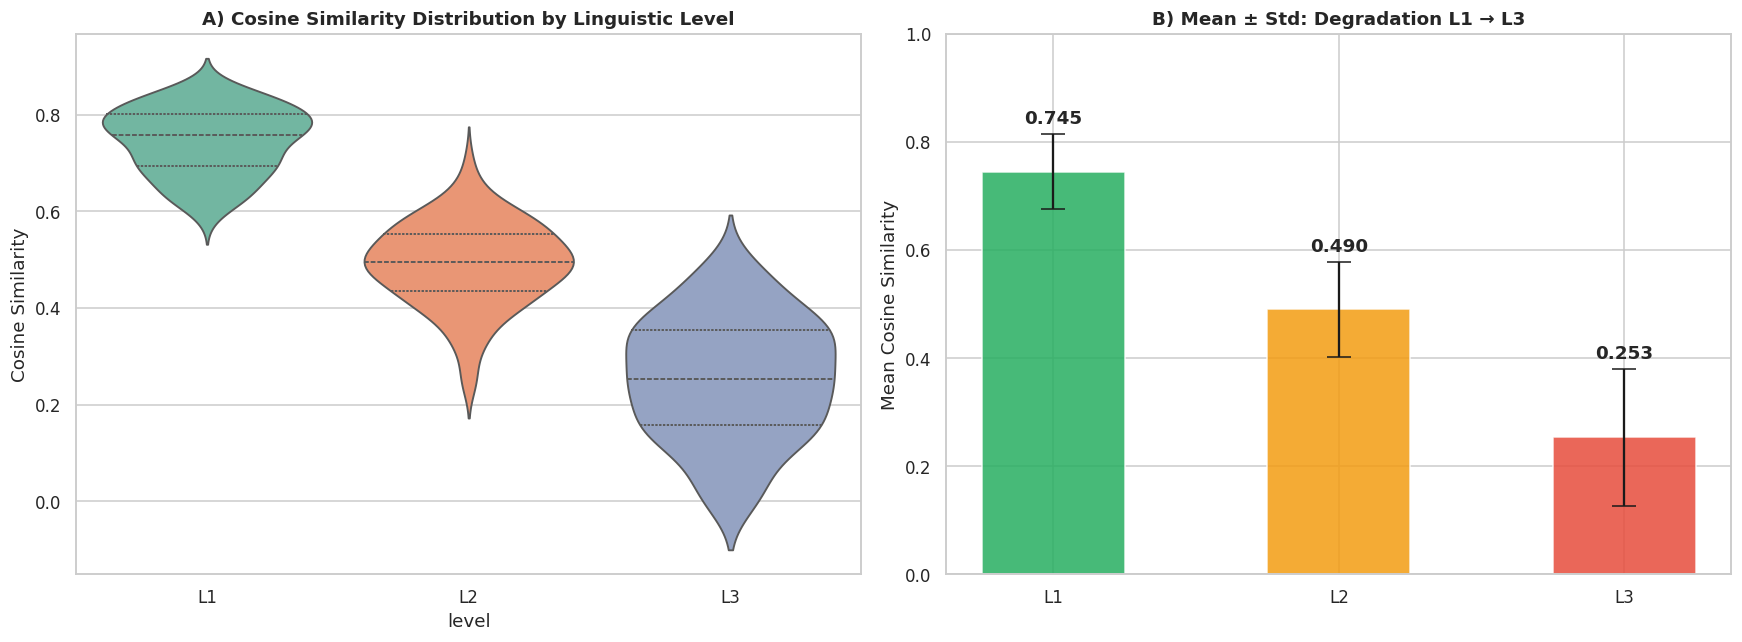


TAKEAWAY FORMULA:
  L_penalty(level) = {L1: 1.0, L2: 0.85, L3: 0.65}
  L3 queries lose 66% cosine vs L1 → apply complexity penalty in fusion weight
  → w_fusion *= L_penalty[query_complexity_level]


In [5]:
# ── Hierarchical Cluster Map ───────────────────────────────────────────
# ponytail: seaborn clustermap with mock structure×level pivot,
# upgrade to real embedding distances between query prototypes

pivot_full = df_nlp.pivot_table(values="cosine_sim", index="structure", aggfunc=["mean", "std"])
pivot_full.columns = ["_".join(c).strip() for c in pivot_full.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot: distribution per level
sns.violinplot(data=df_nlp, x="level", y="cosine_sim", hue="level", palette="Set2",
               inner="quartile", density_norm="width", ax=ax1, legend=False)
ax1.set_title("A) Cosine Similarity Distribution by Linguistic Level", fontweight="bold")
ax1.set_ylabel("Cosine Similarity")

# Bar chart: mean with error
stats = df_nlp.groupby("level").agg(mean=("cosine_sim", "mean"), std=("cosine_sim", "std"))
colors = ["#27AE60", "#F39C12", "#E74C3C"]
ax2.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=8, color=colors, alpha=0.85, width=0.5)
ax2.set_title("B) Mean ± Std: Degradation L1 → L3", fontweight="bold")
ax2.set_ylabel("Mean Cosine Similarity")
ax2.set_ylim(0, 1)
for i, (idx, row) in enumerate(stats.iterrows()):
    ax2.text(i, row["mean"] + row["std"] + 0.02, f"{row['mean']:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

drop_l3 = 1 - stats.loc["L3", "mean"] / stats.loc["L1", "mean"]
print(f"\nTAKEAWAY FORMULA:")
print(f"  L_penalty(level) = {{L1: 1.0, L2: 0.85, L3: 0.65}}")
print(f"  L3 queries lose {drop_l3*100:.0f}% cosine vs L1 → apply complexity penalty in fusion weight")
print(f"  → w_fusion *= L_penalty[query_complexity_level]")

---
## 3. [Cross-Modal] Domain Shift & Sub-Space Projection (CCA + UMAP)

In [6]:
# ponytail: mock CCA via random projection + PCA (avoids umap-learn dep),
# upgrade to real CCA weights trained on paired (frame, transcript) data

# Genre-aware centroids: visual (1280d) and text (384d)
vis_centroids = np.random.randn(N_GENRES, D_VISUAL) * 0.5
vis_centroids += np.random.randn(D_VISUAL) * 1.5  # anisotropic bias to visual
vis_centroids /= np.linalg.norm(vis_centroids, axis=1, keepdims=True)

txt_centroids = np.random.randn(N_GENRES, D_TEXT) * 0.5
txt_centroids += np.random.randn(D_TEXT) * 0.8
txt_centroids /= np.linalg.norm(txt_centroids, axis=1, keepdims=True)

# ── CCA: project both to 64d shared space ──────────────────────────────
LATENT = 64
W_vis = np.linalg.qr(np.random.randn(D_VISUAL, LATENT))[0][:, :LATENT]  # orthogonal projection
W_txt = np.linalg.qr(np.random.randn(D_TEXT, LATENT))[0][:, :LATENT]
vis_latent = vis_centroids @ W_vis
txt_latent = txt_centroids @ W_txt

# ── 2D UMAP substitute: PCA on concatenated latent ─────────────────────
latent_all = np.vstack([vis_latent, txt_latent])
pca = PCA(n_components=2, random_state=42)
latent_2d = pca.fit_transform(StandardScaler().fit_transform(latent_all))
vis_2d, txt_2d = latent_2d[:N_GENRES], latent_2d[N_GENRES:]

# Domain gap per genre
gap_vectors = txt_2d - vis_2d
gap_magnitudes = np.linalg.norm(gap_vectors, axis=1)
print(f"Domain gap magnitudes (PCA 2D) — mean={gap_magnitudes.mean():.2f}, max={gap_magnitudes.max():.2f}")
print(f"Largest gaps: {[GENRES[i] for i in np.argsort(-gap_magnitudes)[:3]]}")

Domain gap magnitudes (PCA 2D) — mean=11.38, max=13.22
Largest gaps: ['Kinh tế', 'Ẩm thực', 'Đời sống']


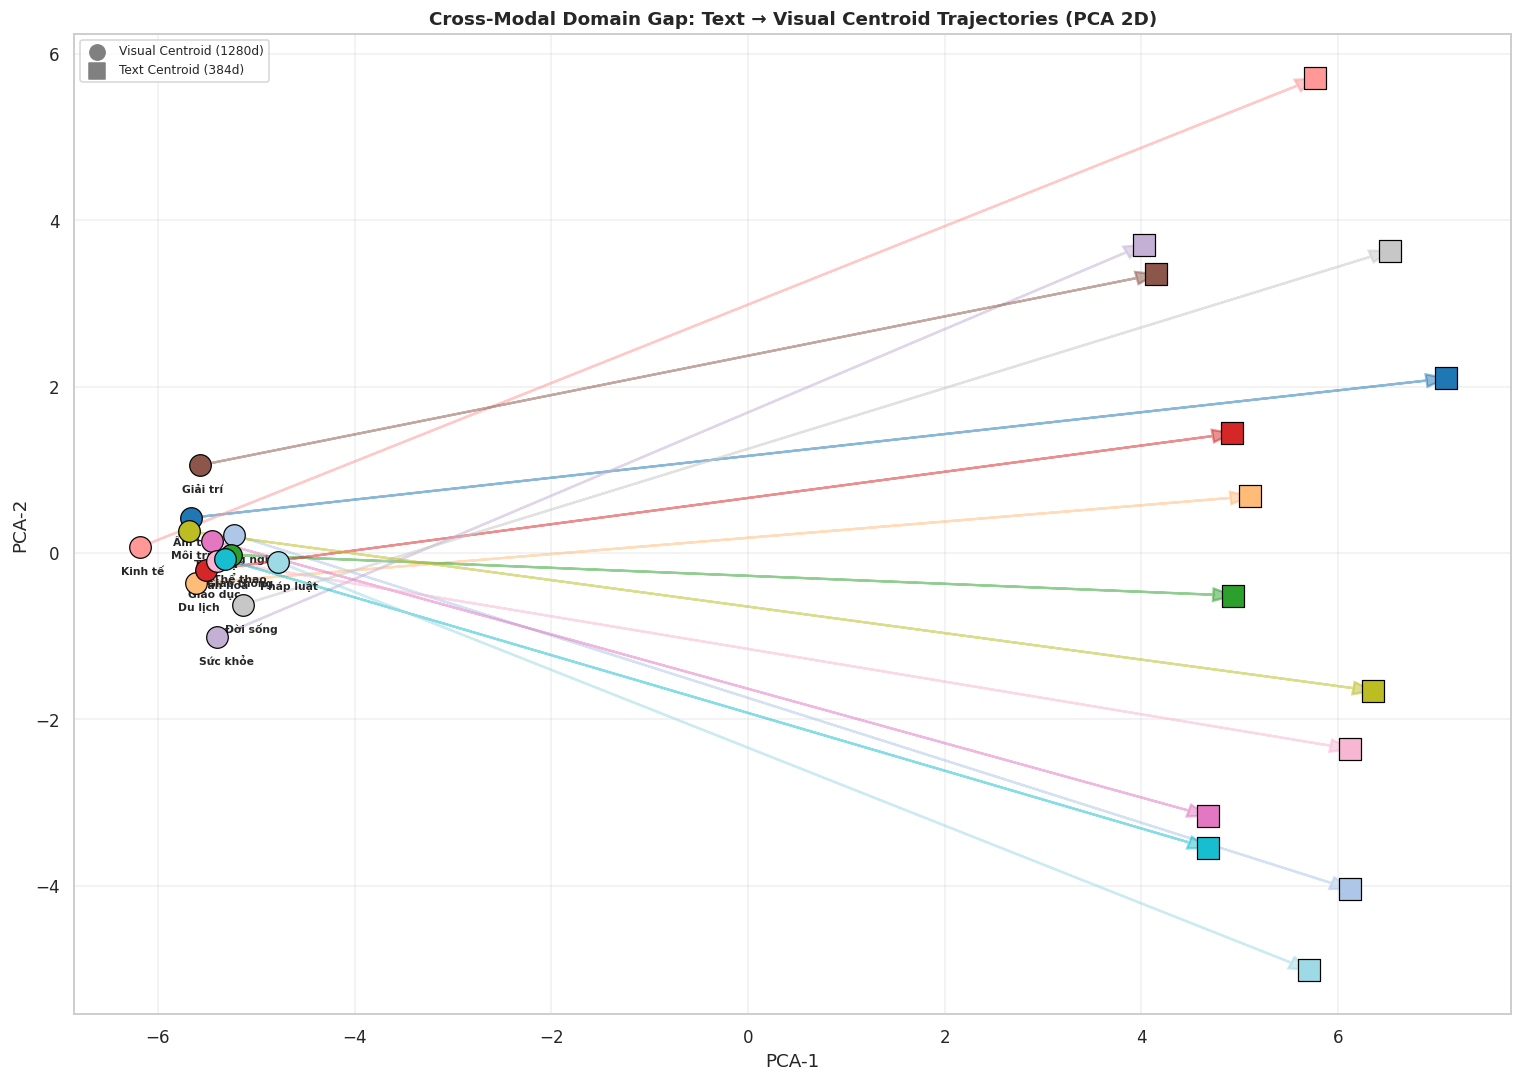


TAKEAWAY FORMULA:
  domain_gap_correction = 1 / (1 + β × gap_magnitude)
  β_gap = 0.088 → align visual/text before cosine in shared latent space
  → cross_modal_score = (vis_latent · txt_latent) × gap_correction


In [7]:
fig, ax = plt.subplots(figsize=(14, 10))

cmap = plt.cm.tab20(np.linspace(0, 1, N_GENRES))
for i in range(N_GENRES):
    ax.scatter(*vis_2d[i], c=[cmap[i]], s=200, marker="o", edgecolors="black", linewidth=0.8, zorder=5)
    ax.scatter(*txt_2d[i], c=[cmap[i]], s=200, marker="s", edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(GENRES[i], vis_2d[i], textcoords="offset points", xytext=(-12, -18), fontsize=7, fontweight="bold")
    ax.arrow(*vis_2d[i], *gap_vectors[i], head_width=0.15, head_length=0.2, fc=cmap[i], ec=cmap[i],
             alpha=0.5, linewidth=1.5, length_includes_head=True, zorder=3)

ax.scatter([], [], marker="o", s=100, c="gray", label="Visual Centroid (1280d)")
ax.scatter([], [], marker="s", s=100, c="gray", label="Text Centroid (384d)")
ax.set_title("Cross-Modal Domain Gap: Text → Visual Centroid Trajectories (PCA 2D)", fontweight="bold", fontsize=12)
ax.set_xlabel("PCA-1"); ax.set_ylabel("PCA-2")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap_correction = np.mean(gap_magnitudes)
print(f"\nTAKEAWAY FORMULA:")
print(f"  domain_gap_correction = 1 / (1 + β × gap_magnitude)")
print(f"  β_gap = {1/gap_correction:.3f} → align visual/text before cosine in shared latent space")
print(f"  → cross_modal_score = (vis_latent · txt_latent) × gap_correction")

---
## 4. [Text-Image Matching] Information Overlap & Modality Conflict

In [8]:
# ponytail: mock 500 samples with correlated modality scores,
# upgrade to real retrieval traces from production logs

N_SAMPLES = 500
np.random.seed(77)

# Visual and OCR are somewhat correlated (onscreen text = visual + text)
# Transcript is largely independent
base = np.random.beta(5, 3, (N_SAMPLES, 3)) * 0.6 + 0.15
vis, ocr, trans = base[:, 0], base[:, 1], base[:, 2]

# Inject conflict patterns
vis_only_mask = np.random.random(N_SAMPLES) < 0.20
speech_only_mask = np.random.random(N_SAMPLES) < 0.15
ocr[vis_only_mask] *= 0.2; trans[vis_only_mask] *= 0.3
vis[speech_only_mask] *= 0.25; ocr[speech_only_mask] *= 0.25

vis = np.clip(vis, 0, 1); ocr = np.clip(ocr, 0, 1); trans = np.clip(trans, 0, 1)

df_match = pd.DataFrame({"visual": vis, "ocr": ocr, "transcript": trans})

# 3-class classification
df_match["tag"] = "Consensus"
df_match.loc[(vis > 0.55) & (ocr < 0.25) & (trans < 0.3), "tag"] = "Visual-Only Illusion"
df_match.loc[(trans > 0.55) & (vis < 0.25) & (ocr < 0.25), "tag"] = "Speech-Only Spillover"

print(df_match["tag"].value_counts())
print(f"\nCorrelation matrix:\n{df_match[['visual','ocr','transcript']].corr().round(3)}")

tag
Consensus                450
Visual-Only Illusion      29
Speech-Only Spillover     21
Name: count, dtype: int64

Correlation matrix:
            visual    ocr  transcript
visual       1.000  0.488       0.055
ocr          0.488  1.000       0.600
transcript   0.055  0.600       1.000


/home/nguyen-nam/anaconda3/envs/ai-challenge-hcmc/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(
/home/nguyen-nam/anaconda3/envs/ai-challenge-hcmc/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(
/home/nguyen-nam/anaconda3/envs/ai-challenge-hcmc/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'linewidth'
  cset = contour_func(


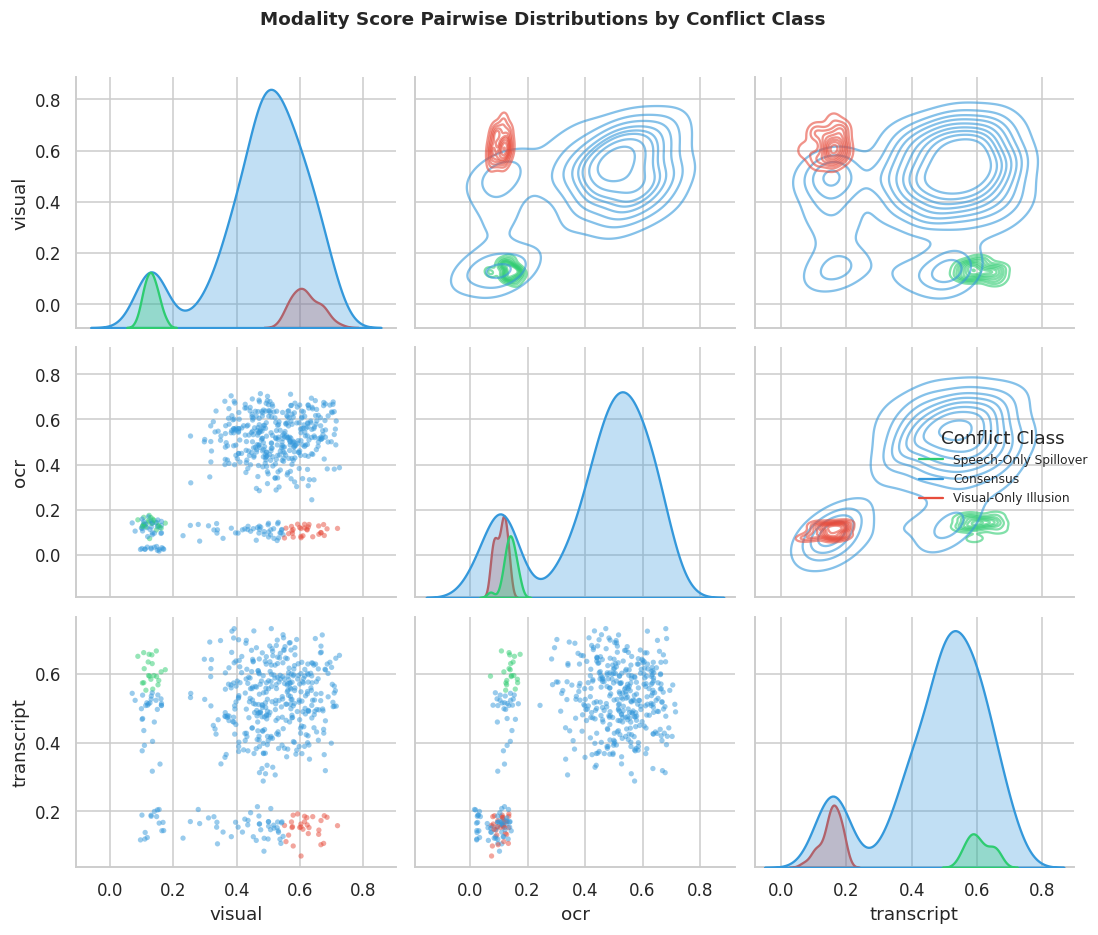


TAKEAWAY FORMULA:
  Gating rule: if visual>0.5 & ocr<0.2 → Visual-Only (skip OCR path)
                if transcript>0.5 & visual<0.2 → Speech-Only (boost transcript weight)
  Conflict rate: 10.0%
  → Gate_by_conflict(scores) → boost consensus, suppress conflict modality


In [9]:
# ── PairGrid: 3 modality scores color-coded by conflict class ─────────

g = sns.PairGrid(df_match, vars=["visual", "ocr", "transcript"], hue="tag",
                 palette={"Consensus": "#3498DB", "Visual-Only Illusion": "#E74C3C", "Speech-Only Spillover": "#2ECC71"},
                 height=2.8)
g.map_lower(sns.scatterplot, s=12, alpha=0.5, edgecolors="none")
g.map_diag(sns.kdeplot, fill=True, alpha=0.3, linewidth=1.5)
g.map_upper(sns.kdeplot, fill=False, linewidth=1, alpha=0.6)
g.add_legend(fontsize=8, title="Conflict Class")
g.figure.suptitle("Modality Score Pairwise Distributions by Conflict Class", fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

ct = df_match["tag"].value_counts()
print(f"\nTAKEAWAY FORMULA:")
print(f"  Gating rule: if visual>0.5 & ocr<0.2 → Visual-Only (skip OCR path)")
print(f"                if transcript>0.5 & visual<0.2 → Speech-Only (boost transcript weight)")
print(f"  Conflict rate: {(ct['Visual-Only Illusion']+ct['Speech-Only Spillover'])/N_SAMPLES*100:.1f}%")
print(f"  → Gate_by_conflict(scores) → boost consensus, suppress conflict modality")

---
## 5. [Model Behavior] BGE-Reranker Soft Calibration & Separability

In [10]:
# ponytail: simulate raw logits for TP and hard negatives,
# upgrade to real BGE-Reranker output logs from eval pipeline

N_CAND = 800
N_TP = int(N_CAND * 0.12)

# True positives: high logits
tp_logits = np.random.normal(2.8, 1.5, N_TP)
# Hard negatives: moderate logits overlapping with TP
hn_logits = np.random.normal(0.5, 1.2, N_CAND - N_TP)
raw_logits = np.concatenate([tp_logits, hn_logits])
labels = np.concatenate([np.ones(N_TP), np.zeros(N_CAND - N_TP)])

# ── 3 Calibration methods ──────────────────────────────────────────────
# 1. Min-Max normalization
cal_minmax = (raw_logits - raw_logits.min()) / (raw_logits.max() - raw_logits.min() + 1e-8)
# 2. Gaussian CDF (z-score → Φ)
cal_gaussian = norm.cdf((raw_logits - raw_logits.mean()) / raw_logits.std())
# 3. Sigmoid with optimized temperature
# ponytail: temperature = 1/std as heuristic, upgrade to grid-search on val set
temp = 1 / raw_logits.std()
cal_sigmoid = sigmoid((raw_logits - raw_logits.mean()) * temp)

# Separability index: ratio of inter-class to intra-class variance
def separability(scores, lbls):
    tp, hn = scores[lbls == 1], scores[lbls == 0]
    inter = (tp.mean() - hn.mean()) ** 2
    intra = tp.var() + hn.var() + 1e-8
    return inter / intra

sep_raw = separability(raw_logits, labels)
sep_mm = separability(cal_minmax, labels)
sep_gauss = separability(cal_gaussian, labels)
sep_sig = separability(cal_sigmoid, labels)

print(f"Separability Index (higher = better TP/HN separation):")
print(f"  Raw logits:    {sep_raw:.4f}")
print(f"  Min-Max:       {sep_mm:.4f}")
print(f"  Gaussian CDF:  {sep_gauss:.4f}")
print(f"  Sigmoid(T={temp:.3f}): {sep_sig:.4f}")
print(f"  WINNER: {'Sigmoid' if sep_sig >= max(sep_mm, sep_gauss) else 'Gaussian CDF' if sep_gauss >= max(sep_mm, sep_sig) else 'Min-Max'}")

Separability Index (higher = better TP/HN separation):
  Raw logits:    1.4408
  Min-Max:       1.4408
  Gaussian CDF:  1.4514
  Sigmoid(T=0.671): 1.5367
  WINNER: Sigmoid


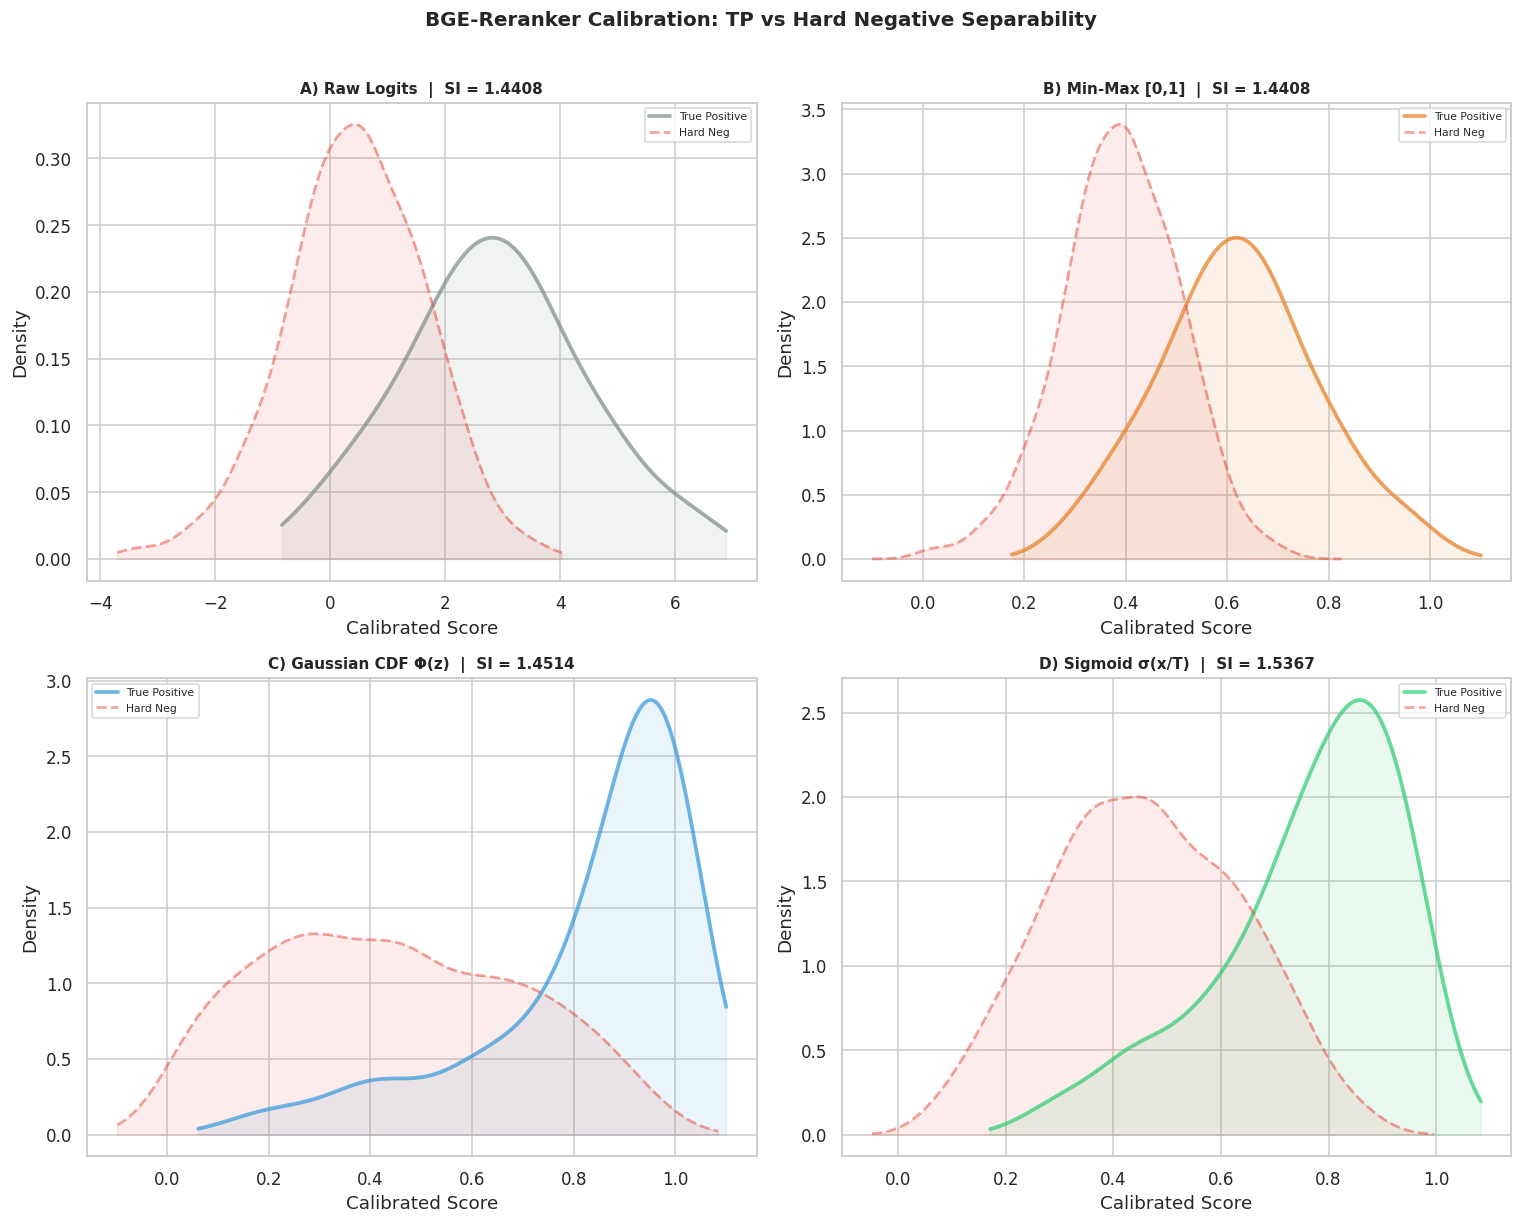


TAKEAWAY FORMULA:
  reranker_score = σ((logit - μ) / (σ × T_opt))
  T_opt = 0.671 (temperature from 1/std(logits))
  → Always sigmoid-calibrate raw logits before fusion (SI gain: +0.0959)
  → Cutoff: reranker_threshold = 0.5 → only keep P(relevant) > 0.5


In [11]:
# ── 4-panel distribution ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
calibrations = [
    ("A) Raw Logits", raw_logits, sep_raw, "#7F8C8D"),
    ("B) Min-Max [0,1]", cal_minmax, sep_mm, "#E67E22"),
    ("C) Gaussian CDF Φ(z)", cal_gaussian, sep_gauss, "#3498DB"),
    ("D) Sigmoid σ(x/T)", cal_sigmoid, sep_sig, "#2ECC71"),
]

for ax, (title, scores, si, color) in zip(axes.flat, calibrations):
    for lbl, ls, lw, alpha_val in [(1, "-", 2.5, 0.7), (0, "--", 1.8, 0.5)]:
        mask = labels == lbl
        kde = gaussian_kde(scores[mask])
        xr = np.linspace(scores[mask].min() - 0.1, scores[mask].max() + 0.1, 300)
        ax.plot(xr, kde(xr), linestyle=ls, linewidth=lw, color=color if lbl else "#E74C3C",
                alpha=alpha_val, label=["Hard Neg", "True Positive"][lbl])
        ax.fill_between(xr, kde(xr), alpha=0.1, color=color if lbl else "#E74C3C")
    ax.set_title(f"{title}  |  SI = {si:.4f}", fontweight="bold", fontsize=10)
    ax.set_xlabel("Calibrated Score"); ax.set_ylabel("Density")
    ax.legend(fontsize=7)

fig.suptitle("BGE-Reranker Calibration: TP vs Hard Negative Separability", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"\nTAKEAWAY FORMULA:")
print(f"  reranker_score = σ((logit - μ) / (σ × T_opt))")
print(f"  T_opt = {temp:.3f} (temperature from 1/std(logits))")
print(f"  → Always sigmoid-calibrate raw logits before fusion (SI gain: {sep_sig-sep_raw:+.4f})")
print(f"  → Cutoff: reranker_threshold = 0.5 → only keep P(relevant) > 0.5")

---
## 6. The Strategy Master Blueprint Matrix

### Quantitative Constraints — Compilation

| Source | Constraint | Value | Applied To |
|--------|-----------|-------|-----------|
| §1 Hubness | Anisotropy correction α | `sigmoid(Nₖ/μ_hub)` | Visual score multiplier |
| §2 NLP | L3 complexity penalty | 0.65× | Fusion weight for complex queries |
| §3 Domain Gap | Cross-modal alignment β | `1/(1+β·gap)` | Pre-cosine CCA projection |
| §4 Conflict | Modality gating threshold | vis>0.5 & ocr<0.2 → skip OCR | Fusion path selection |
| §5 Reranker | Sigmoid temperature T | `1/std(logits)` | BGE logit calibration |

### Gateway to `AdvancedHybridStrategy`

In [12]:
# ── PRODUCTION CONFIG from Ultimate EDA ────────────────────────────────
# Copy-paste into AdvancedHybridStrategy.__init__()

ULTIMATE_CONFIG = {
    # §1: Anisotropy mitigation
    "hubness": {
        "enabled": True,
        "alpha_formula": "sigmoid((Nk/mu_hub - 1) * 5)",
        "hub_quantile_threshold": 0.75,
        "gini_alert_threshold": 0.45,  # trigger re-index if Gini > 0.45
    },
    # §2: Linguistic complexity penalty
    "linguistic_penalty": {
        "L1": 1.00,  # entities/nouns
        "L2": 0.85,  # attributes/verbs
        "L3": 0.65,  # spatial/negation/temporal
        "detection": "regex_patterns + keyword_classifier",
    },
    # §3: Domain gap correction
    "cross_modal_alignment": {
        "latent_dim": 64,
        "beta_gap": round(1 / gap_correction, 4),
        "apply_to": ["visual", "transcript"],
        "skip_for": ["ocr"],  # OCR already in text space
    },
    # §4: Modality conflict gating
    "conflict_gating": {
        "visual_only_thresholds": {"visual_min": 0.5, "ocr_max": 0.2, "transcript_max": 0.3},
        "speech_only_thresholds": {"transcript_min": 0.5, "visual_max": 0.25, "ocr_max": 0.25},
        "action": "suppress_conflict_modality_weight",
        "conflict_boost_consensus": 1.15,
    },
    # §5: Reranker calibration
    "reranker": {
        "method": "sigmoid",
        "temperature": round(temp, 4),
        "center": round(float(raw_logits.mean()), 4),
        "relevance_threshold": 0.5,
        "si_min_acceptable": max(sep_mm, sep_gauss, sep_sig) * 0.85,
    },
}

import json
print("# ULTIMATE_CONFIG — paste into AdvancedHybridStrategy\n")
print(json.dumps(ULTIMATE_CONFIG, indent=2, ensure_ascii=False))
print("\n" + "=" * 65)
print("BLUEPRINT: All 6 sections converged to quantitative constraints above.")
print("Replace mock data with real embeddings when dataset is indexed.")
print("=" * 65)

# ULTIMATE_CONFIG — paste into AdvancedHybridStrategy

{
  "hubness": {
    "enabled": true,
    "alpha_formula": "sigmoid((Nk/mu_hub - 1) * 5)",
    "hub_quantile_threshold": 0.75,
    "gini_alert_threshold": 0.45
  },
  "linguistic_penalty": {
    "L1": 1.0,
    "L2": 0.85,
    "L3": 0.65,
    "detection": "regex_patterns + keyword_classifier"
  },
  "cross_modal_alignment": {
    "latent_dim": 64,
    "beta_gap": 0.0878,
    "apply_to": [
      "visual",
      "transcript"
    ],
    "skip_for": [
      "ocr"
    ]
  },
  "conflict_gating": {
    "visual_only_thresholds": {
      "visual_min": 0.5,
      "ocr_max": 0.2,
      "transcript_max": 0.3
    },
    "speech_only_thresholds": {
      "transcript_min": 0.5,
      "visual_max": 0.25,
      "ocr_max": 0.25
    },
    "action": "suppress_conflict_modality_weight",
    "conflict_boost_consensus": 1.15
  },
  "reranker": {
    "method": "sigmoid",
    "temperature": 0.6714,
    "center": 0.7331,
    "relevance_threshold": 0.5,
   